In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('gurgaon_feature_selection.csv')
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,unfurnished,Low,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,unfurnished,Mid,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,unfurnished,High,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,semifurnished,Mid,High
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,unfurnished,Mid,High


In [3]:
x = df.drop(columns = ['price'])
y = df['price']

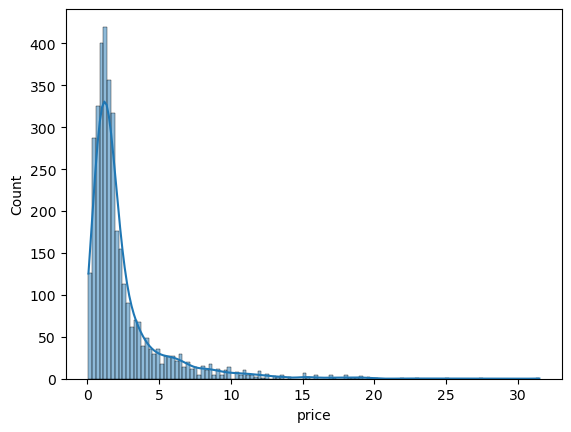

In [4]:
sns.histplot(df['price'], kde = True)
plt.show()

#### Since price data is right skewed, it will be better option to take log since models works better on normal-like distributions. 

In [17]:
# Since price column can't be negative, take log1p()
y_transformed = np.log1p(y)

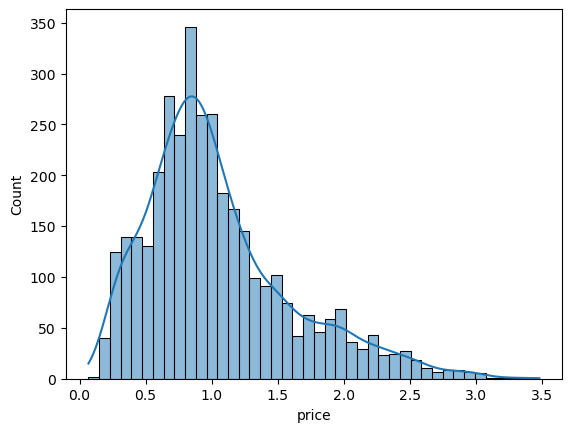

In [18]:
sns.histplot(y_transformed, kde = True)
plt.show()

### Encoding

In [7]:
col_encode = ['property_type', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

In [8]:
for col in col_encode:
    print(f"\n{col}:", df[col].unique())


property_type: ['flat' 'house']

balcony: ['2' '1' '3+' '3' '0']

agePossession: ['New Property' 'Relatively New' 'Old Property' 'Moderately Old'
 'Under Construction']

furnishing_type: ['unfurnished' 'semifurnished' 'furnished']

luxury_category: ['Low' 'High' 'Medium']

floor_category: ['Low' 'Mid' 'High']


In [9]:
ordinal_cols = ['agePossession','furnishing_type','luxury_category','floor_category']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Old Property','Moderately Old','Relatively New','New Property','Under Construction'],
    ['unfurnished','semifurnished','furnished'],
    ['Low','Medium','High'],
    ['Low','Mid','High']
])

In [10]:
import category_encoders as ce
print(ce.__version__)

2.8.1


In [11]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'study room', 'servant room', 'store room']),
        ('ordinal', ordinal_encoder, ordinal_cols),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False),['property_type', 'balcony']),
        ('target', ce.TargetEncoder(), ['sector'])
    ],
    remainder = 'passthrough'
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

model_dict = {
    'linear_reg':LinearRegression(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'xgboost':XGBRegressor()
}

In [15]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, x, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    x_train, x_test, y_train, y_test = train_test_split(x,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(x_train,y_train)
    
    y_pred = pipeline.predict(x_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [19]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [20]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [21]:
model_df.sort_values(['mae'])

,name,r2,mae
4,xgboost,0.894594,0.428133
1,random forest,0.893453,0.445046
2,extra trees,0.894697,0.451755
3,gradient boosting,0.885361,0.507699
0,linear_reg,0.830903,0.687659


### Hyperparameter Tuning

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [25]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__n_estimators': [200,300,400,500,600],
    'regressor__max_depth': [None,10,20,30],
    'regressor__min_samples_split': [2,5,10],
    'regressor__min_samples_leaf': [1,2,4],
    'regressor__max_features': ['sqrt','log2']
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

search.fit(x, y_transformed)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['bedRoom',
                                                                                'bathroom',
                                                                                'built_up_area',
                                                                                'study '
                                                                                'room',
                                                                                'servant '
                                                                                'room',
                                                                                'store '
                                                                                'room']),
                                                                              ('ordinal',
                                                                               OrdinalEncoder(categories=[['Old '
                                                                                                           'Property',
                                                                                                           'Moderately '
                                                                                                           'Old',
                                                                                                           'Relatively '
                                                                                                           'New',
                                                                                                           'New '
                                                                                                           'Property',
                                                                                                           'Under '
                                                                                                           'Const...
                                                                               TargetEncoder(),
                                                                               ['sector'])])),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [None, 10, 20,
                                                                 30],
                                        'regressor__max_features': ['sqrt',
                                                                    'log2'],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [200, 300,
                                                                    400, 500,
                                                                    600]},
                   random_state=42, scoring='r2')

In [26]:
search.best_params_

{'regressor__n_estimators': 400,
 'regressor__min_samples_split': 2,
 'regressor__min_samples_leaf': 1,
 'regressor__max_features': 'sqrt',
 'regressor__max_depth': 30}

In [27]:
search.best_score_

np.float64(0.8932229540625155)

In [28]:
x

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category,luxury_category
0,flat,sector 36,3,2,2,New Property,850.0,0,0,0,unfurnished,Low,Low
1,flat,sector 89,2,2,2,New Property,1226.0,1,1,0,unfurnished,Mid,Low
2,flat,sohna road,2,2,1,New Property,1000.0,0,0,0,unfurnished,High,Low
3,flat,sector 92,3,4,3+,Relatively New,1615.0,0,1,0,semifurnished,Mid,High
4,flat,sector 102,2,2,1,Relatively New,582.0,0,0,1,unfurnished,Mid,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,flat,sector 84,2,2,1,Relatively New,532.0,0,0,0,unfurnished,Mid,Medium
3551,house,sector 109,5,5,3+,Relatively New,6228.0,1,1,1,unfurnished,Low,High
3552,flat,sector 2,1,1,1,Moderately Old,665.0,0,0,0,semifurnished,Mid,Medium
3553,house,sector 43,5,6,3,Moderately Old,5490.0,1,1,1,unfurnished,Low,Medium


### XGBRegressor Tuning

In [29]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

In [30]:
param_dist = {
    'regressor__n_estimators': [300,500,700,900],
    'regressor__max_depth': [3,4,5,6],
    'regressor__learning_rate': [0.01,0.03,0.05,0.1],
    'regressor__subsample': [0.7,0.8,0.9,1],
    'regressor__colsample_bytree': [0.7,0.8,0.9,1],
    'regressor__gamma': [0,0.1,0.2,0.3]
}

In [31]:
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

search.fit(x, y_transformed)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['bedRoom',
                                                                                'bathroom',
                                                                                'built_up_area',
                                                                                'study '
                                                                                'room',
                                                                                'servant '
                                                                                'room',
                                                                                'store '
                                                                                'room']),
                                                                              ('ordinal',
                                                                               OrdinalEncoder(categories=[['Old '
                                                                                                           'Property',
                                                                                                           'Moderately '
                                                                                                           'Old',
                                                                                                           'Relatively '
                                                                                                           'New',
                                                                                                           'New '
                                                                                                           'Property',
                                                                                                           'Under '
                                                                                                           'Const...
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'regressor__colsample_bytree': [0.7,
                                                                        0.8,
                                                                        0.9,
                                                                        1],
                                        'regressor__gamma': [0, 0.1, 0.2, 0.3],
                                        'regressor__learning_rate': [0.01, 0.03,
                                                                     0.05,
                                                                     0.1],
                                        'regressor__max_depth': [3, 4, 5, 6],
                                        'regressor__n_estimators': [300, 500,
                                                                    700, 900],
                                        'regressor__subsample': [0.7, 0.8, 0.9,
                                                                 1]},
                   random_state=42, scoring='r2')

In [32]:
search.best_score_

np.float64(0.9044109616170013)

In [33]:
search.best_params_

{'regressor__subsample': 0.8,
 'regressor__n_estimators': 900,
 'regressor__max_depth': 5,
 'regressor__learning_rate': 0.03,
 'regressor__gamma': 0,
 'regressor__colsample_bytree': 0.7}

In [34]:
best_model = search.best_estimator_

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x, y_transformed, test_size=0.2, random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_pred = np.expm1(y_pred)

mae = mean_absolute_error(np.expm1(y_test), y_pred)
print("MAE:", mae)

MAE: 0.43737888359570803


In [36]:
best_model.fit(x, y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedRoom', 'bathroom',
                                                   'built_up_area',
                                                   'study room', 'servant room',
                                                   'store room']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Old '
                                                                              'Property',
                                                                              'Moderately '
                                                                              'Old',
                                                                              'Relatively '
                                                                              'New',
                                                                              'New '
                                                                              'Property',
                                                                              'Under '
                                                                              'Construction'],
                                                                             ['unfurnished',
                                                                              'semifurnished'...
                              feature_types=None, feature_weights=None, gamma=0,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=900, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Saving the Pipeline

In [38]:
import pickle
pickle.dump(best_model, open('Gurgaon_Model.pkl', 'wb'))

### Lets do one final check

In [40]:
import pickle

model = pickle.load(open('Gurgaon_Model.pkl', 'rb'))

In [51]:
data = [['house', 'sector 102', 4, 3, '3+', 'New Property', 2750, 0, 0, 0, 'unfurnished', 'Low', 'Low']]
columns = ['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'study room', 'servant room', 'store room',
       'furnishing_type', 'floor_category', 'luxury_category']

# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category,luxury_category
0,house,sector 102,4,3,3+,New Property,2750,0,0,0,unfurnished,Low,Low


In [53]:
x.head(1)

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category,luxury_category
0,flat,sector 36,3,2,2,New Property,850.0,0,0,0,unfurnished,Low,Low


In [54]:
np.expm1(model.predict(one_df))

array([3.3381524], dtype=float32)

In [48]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedRoom', 'bathroom',
                                                   'built_up_area',
                                                   'study room', 'servant room',
                                                   'store room']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Old '
                                                                              'Property',
                                                                              'Moderately '
                                                                              'Old',
                                                                              'Relatively '
                                                                              'New',
                                                                              'New '
                                                                              'Property',
                                                                              'Under '
                                                                              'Construction'],
                                                                             ['unfurnished',
                                                                              'semifurnished'...
                              feature_types=None, feature_weights=None, gamma=0,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=900, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [49]:
from sklearn.utils.validation import check_is_fitted
check_is_fitted(model)